# Introduction to SQL: Concepts, Standards, and Command Categories


This notebook walks through the same material your professor covered, but organized cell-by-cell so each concept has its own explanation followed by a runnable (or illustrative) SQL example. The notebook assumes a `Students` table for consistency with the original notes.

**Setup note:** If you're running this with a real SQL kernel (e.g. `ipython-sql` + SQLite, or a SQL Server connection), the setup cell below creates a sample `Students` table so every query in this notebook actually executes. If you're just reading through conceptually, you can skip execution and treat the code cells as reference.

In [ ]:
-- OPTIONAL SETUP (only if you're running this with a live SQL connection)
-- Creates a sample Students table so the queries below can actually execute.

CREATE TABLE Students (
    StudentID INT,
    Name NVARCHAR(50),
    GPA DECIMAL(3,2),
    Department NVARCHAR(50)
);

INSERT INTO Students VALUES (1, 'Ali', 3.8, 'Computer Science');
INSERT INTO Students VALUES (2, 'Reza', 3.2, 'Statistics');
INSERT INTO Students VALUES (3, 'Sara', 3.9, 'Statistics');
INSERT INTO Students VALUES (4, 'Mina', 2.9, 'Mathematics');

## 1. What Is SQL?

**SQL** stands for **Structured Query Language** — a language designed specifically for working with **relational databases** (databases organized into tables with rows and columns, related to each other through keys).

With SQL, you can:
- Create databases and tables
- Insert new data
- Modify existing data
- Delete data
- Search and filter data
- Sort and organize results
- Generate reports and summaries
- Manage which users can access what

The example below retrieves *everything* from the `Students` table — this is the simplest possible SQL statement, and a good starting point for understanding the language's basic shape: an action (`SELECT`) followed by a target (`FROM Students`).

In [ ]:
SELECT *
FROM Students;

-- Meaning: "Retrieve all columns and all rows from the Students table."
-- The asterisk (*) is a wildcard meaning: every column.

## 2. Where Did the Name Come From? (SEQUEL → SQL)

This part is mostly **historical context**, but it's useful for understanding why some naming conventions in the field can feel inconsistent.

SQL was originally developed at IBM in the 1970s under the name **SEQUEL**, which stood for:

> **S**tructured **E**nglish **Q**uery **L**anguage

Later, for trademark reasons, the name was shortened to **SQL** (Structured Query Language), which is the name that stuck.

**A correction worth noting for your own study materials:** your professor's notes wrote "SEQL" — the historically accurate acronym is **SEQUEL**, not SEQL. Small distinction, but worth writing correctly if this goes into your own repository.

```
SEQUEL  →  Structured English Query Language
   ↓
 SQL    →  Structured Query Language
```

## 3. SQL Is a Standardized Language

Unlike a proprietary tool built by a single company, SQL is a **standard** — meaning its core syntax and behavior are defined by independent standards bodies:

- **ANSI** — American National Standards Institute
- **ISO** — International Organization for Standardization

This standardization is *why* SQL knowledge transfers across different database systems: the fundamentals of `SELECT`, `WHERE`, `JOIN`, etc. behave similarly everywhere.

**Important nuance:** Microsoft SQL Server does not have its own competing "SQL language." Instead, it *implements* the SQL standard and then extends it with its own proprietary features — which brings us to the next point: dialects.

## 4. SQL Dialects Across Different Database Systems

While SQL is standardized, every major database system adds its own **extensions** — proprietary features layered on top of standard SQL. These extended versions are often called **dialects**.

| Database System | Dialect / Extension |
|---|---|
| Microsoft SQL Server | **T-SQL** (Transact-SQL) |
| Oracle Database | **PL/SQL** |
| PostgreSQL | PostgreSQL SQL / **PL/pgSQL** |
| MySQL | MySQL SQL |

For this course, since you'll be working in **Microsoft SQL Server**, the dialect you're learning is **T-SQL**. Basic `SELECT` statements look identical across dialects, but as you go further (stored procedures, variables, error handling), the syntax starts to diverge.

In [ ]:
-- This is standard SQL AND valid T-SQL — the basics overlap across dialects
SELECT *
FROM Students;

## 5. Why SQL Matters for Data Roles

Three roles were highlighted as heavy SQL users — and given your own trajectory (Applied Math → Data Science → Financial Modelling PhD), this is directly relevant to your work:

### Data Analyst
SQL is often the **primary daily tool** for:
- Extracting relevant subsets of data
- Filtering based on business conditions
- Aggregating (totals, averages, counts)
- Producing reports

### Data Engineer
SQL underlies:
- Database design and maintenance
- **ETL/ELT** pipelines (Extract, Transform, Load)
- Building and maintaining data warehouses
- Data transformation logic

### Data Scientist
SQL is typically the **first step before Python/R analysis**:
- Pulling only the relevant dataset out of a much larger database
- Pre-filtering millions of records down to a workable sample
- Feature engineering directly at the query level
- Exploratory data analysis before moving into statistical modeling

**Practical example:** imagine a database with 50 million transaction records. Rather than loading all of it into Python (which would be slow and memory-heavy), you'd use SQL to filter down to exactly the rows and columns you need first.

In [ ]:
-- Example: a Data Analyst-style aggregation query
SELECT Department, COUNT(*) AS NumberOfStudents, AVG(GPA) AS AverageGPA
FROM Students
GROUP BY Department;

-- This counts students per department and computes the average GPA per group —
-- exactly the kind of summary a Data Analyst would build for a report.

## 6. Where SQL Fits Among Programming Language Generations

This section places SQL within a broader historical classification of programming languages, based on their level of abstraction from hardware. **Note:** this classification (1GL–4GL) is a *traditional teaching framework*, not a strict, universally agreed-upon technical standard — worth keeping in mind if you cite it elsewhere.

### 1GL — First Generation Language (Machine Code)
Pure binary instructions executed directly by the CPU:
```
010101001111010101...
```
No abstraction at all — this is literally what the hardware reads.

### 2GL — Second Generation Language (Assembly)
Slightly more human-readable, but still tightly coupled to hardware architecture:
```asm
MOV AX, BX
ADD AX, 1
```
Each instruction still maps closely to a specific CPU operation.

### 3GL — Third Generation Languages
Higher-level languages where the programmer works with more abstraction from the hardware: **C, C++, Java, C#, Python, Pascal**, etc.
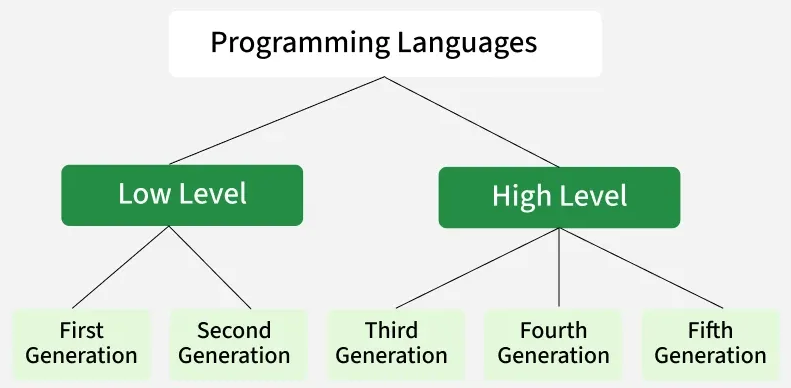


In [1]:
# Example of 3GL abstraction (Python) — no direct hardware/register manipulation needed
x = 10
y = 20
z = x + y
print(z)  # 30

30


### 4GL — Fourth Generation Languages (SQL is typically placed here)

The defining idea of a 4GL is a shift in *what the programmer specifies*:

> Instead of describing **how** to perform a task step-by-step, you describe **what result** you want — and the underlying engine figures out the "how."

Compare this SQL query:
```sql
SELECT Name
FROM Students
WHERE GPA > 3;
```
...to what you'd have to do at a lower level:
```
Go to this disk block
Read these bytes
Move them to this memory address
Compare them
...
```

With SQL, you simply state your intent — "find students with GPA above 3" — and the **Database Engine** decides the actual execution strategy (which index to use, in what order to scan the table, etc.). This declarative nature is the single biggest conceptual difference between SQL and languages like Python or C++.

In [ ]:
SELECT Name
FROM Students
WHERE GPA > 3;

-- You never tell SQL Server *how* to search — you only describe the condition.
-- The engine handles execution strategy internally.

## 9. How a Query Flows: Input → Process → Output

A simple mental model for what happens when you run a query:

```
Input (your SQL query)
        ↓
 Database Engine
        ↓
     Process
        ↓
     Output (result set)
```

Breaking down each stage using the query below:

In [ ]:
SELECT *
FROM Students
WHERE GPA > 3;

- **Input:** the query text itself, as written above.
- **Process:** SQL Server (or whichever engine you're using) performs several internal steps:
  1. **Parses** the query (checks syntax, understands structure)
  2. Builds an **execution plan** (decides the most efficient way to retrieve the data)
  3. Locates the required data (from memory or disk)
  4. Applies the `WHERE GPA > 3` condition to filter rows
- **Output:** the final filtered result set is returned to you.

This is worth understanding conceptually because it explains *why* the same query can sometimes run fast and sometimes slow — the engine's execution plan depends on data volume, indexes, and current memory state.

## 10. The Five SQL Command Categories

This is arguably the most important structural framework in the whole lecture — nearly every SQL command you'll ever write falls into one of these five categories.

### DDL — Data Definition Language
Defines or modifies the **structure** of database objects (tables, schemas, etc.) — not the data inside them.

Commands: `CREATE`, `ALTER`, `DROP`

In [ ]:
CREATE TABLE Students
(
    StudentID INT,
    Name NVARCHAR(50)
);

-- This defines a new table structure. No data has been inserted yet —
-- DDL only concerns the "shape" of the database.

### DML — Data Manipulation Language
Changes the **actual data** stored inside existing structures.

Commands: `INSERT`, `UPDATE`, `DELETE`

In [ ]:
INSERT INTO Students (StudentID, Name)
VALUES (1, 'Ali');

UPDATE Students
SET Name = 'Reza'
WHERE StudentID = 1;

-- INSERT adds new rows; UPDATE modifies existing ones.
-- Both change data, not structure — that's what makes them DML.

### DQL — Data Query Language
Used purely to **retrieve** data, without changing anything.

Command: `SELECT`

This is the category your professor is about to focus on. Its purpose is **data retrieval** — reading data, not modifying it.

In [ ]:
SELECT *
FROM Students;

-- Pure retrieval — no data is created, changed, or removed by this statement.

### DCL — Data Control Language
Manages **permissions and access control** — who is allowed to do what.

Commands: `GRANT`, `DENY`, `REVOKE`

In [ ]:
GRANT SELECT
ON Students
TO User1;

-- This grants User1 permission to read (SELECT) from the Students table,
-- without giving them permission to modify or delete anything.

### TCL — Transaction Control Language
Manages **transactions** — groups of operations that should succeed or fail as a single unit.

Commands: `COMMIT`, `ROLLBACK`

**Correction worth noting:** the original notes wrote "Transact Control Language" — the standard and correct term is **Transaction Control Language**.

In [ ]:
BEGIN TRANSACTION;

UPDATE Students
SET GPA = 4
WHERE StudentID = 1;

ROLLBACK;

-- The UPDATE runs, but ROLLBACK undoes it entirely — as if it never happened.
-- This is essential for maintaining data integrity when something goes wrong
-- mid-operation (e.g., a bank transfer that fails halfway through).

###  DQL in Practice: Beyond Just "Viewing a Table"

It's worth emphasizing that `SELECT` — the sole command in DQL — is far more powerful than simply "look at the whole table." It's the foundation for filtering, shaping, and summarizing data.

**Filtering** — restrict rows based on a condition:

In [ ]:
SELECT *
FROM Students
WHERE GPA > 3;

**Selecting specific columns** — instead of every column:

In [ ]:
SELECT Name, GPA
FROM Students;

**Sorting** — control the order of results:

In [ ]:
SELECT *
FROM Students
ORDER BY GPA DESC;

-- DESC = descending (highest GPA first). Use ASC for ascending order.

**Reporting / Aggregation** — this is where DQL becomes genuinely analytical, using functions such as:
```
GROUP BY, COUNT(), SUM(), AVG(), MAX(), MIN()
```
These will be covered in more depth soon, but this is the direction `SELECT` eventually grows into — from simple lookups to full analytical reporting.

## 11. Development vs. Production Environments

This distinction matters for understanding *how* SQL is actually used in real organizations, not just in a classroom.

### Development
Typically happens on your own machine:
```
Developer → SQL Query → SQL Server → Database
```
You have direct access to write and test queries freely.

### Production
The real, live environment that actual end users interact with:
```
End User → Application → Production Server → SQL Server → Database → Disk / Memory
```
**Key point:** end users almost never interact with SQL Server directly. Instead, an **application layer** sits between them and the database — the application executes the necessary queries on the user's behalf. This is also a safety mechanism: it prevents end users from running arbitrary, potentially destructive queries directly against production data.

## 12. How SQL Server Retrieves Data: Disk vs. Memory

Understanding where data physically lives helps explain performance behavior.

```
Database Files
      ↓
    Disk
      ↓
 SQL Server
      ↓
Memory / Buffer Pool
      ↓
Query Processing
      ↓
   Result
```

Data is permanently stored on **disk** as database files. However, SQL Server tries to avoid slow disk reads whenever possible by keeping frequently accessed data in the **Buffer Pool** (an area of memory/RAM).

**Important nuance:** SQL Server does *not* always read from disk for every `SELECT`. If the requested data page is already cached in memory from a previous query, it will be served from the Buffer Pool instead — which is significantly faster. This is a big part of why database performance tuning often focuses heavily on memory management and indexing.

## 13. Classic Sample Databases

Two legacy Microsoft sample databases are commonly referenced in SQL education:

- **Pubs**
- **Northwind** — especially well-known, historically used in countless SQL tutorials and textbooks

**For your own reference:** Modern SQL Server learning materials have largely moved on to **AdventureWorks** as the standard sample database, since it better reflects realistic, modern business data structures. If you're setting up practice environments today, AdventureWorks (or AdventureWorksLT for a lighter version) is the more current choice.

## 14. SQL Keywords Are Case-Insensitive

The following three statements are functionally identical in SQL Server:

In [ ]:
select * from Students;

Select * From Students;

SELECT * FROM Students;

**Important caveat:** this case-insensitivity applies to **SQL keywords** (`SELECT`, `FROM`, `WHERE`, etc.). Whether *data values* or *identifiers* (table/column names) are treated as case-sensitive can depend on the database's **collation settings** — so don't assume this extends to everything in a query, especially when comparing string data.

**Best practice convention** (not a hard rule): many developers write SQL keywords in UPPERCASE and table/column names in the case they were originally defined, purely for readability — as seen throughout this notebook.

## 15. Indentation and Readability

SQL doesn't require any particular formatting to run correctly — the query below works exactly the same as a nicely formatted one:

In [ ]:
SELECT Name,GPA,Major FROM Students WHERE GPA>3 ORDER BY GPA DESC;

But it's much harder to read at a glance. Compare it to the same query, properly indented:

In [ ]:
SELECT
    Name,
    GPA,
    Major
FROM Students
WHERE GPA > 3
ORDER BY GPA DESC;

-- Same result, same execution — just far easier for a human to scan and debug.
-- This becomes increasingly important as queries grow more complex
-- (multiple JOINs, subqueries, CASE statements, etc.)

## 16. Executing Queries in SSMS (SQL Server Management Studio)

To run a query in SSMS, you can:
- Press **F5**, or
- Click the **Execute** button

The result set appears in the **Results** pane below your query window.

*(Note: this is specific to SSMS — if you're running SQL through Jupyter with a SQL kernel or `ipython-sql`, execution works differently — typically by running the cell itself, as in this notebook.)*

## 17. The Semicolon as Statement Terminator

The semicolon (`;`) marks the end of a SQL statement:

In [ ]:
SELECT *
FROM Students;

**Practical note:** In SQL Server, many single statements will run fine *without* a trailing semicolon. However:
- It's considered **good practice** to always include it
- It becomes **required** in certain contexts — for example, before a Common Table Expression (`WITH` clause) or when running multiple statements together
- Other database systems (like PostgreSQL) are much stricter about requiring it

Building the habit early will save you from confusing errors later.

## Summary: The Full Conceptual Path

Putting it all together, here's the logical progression this lecture followed:

```
Programming Languages
        ↓
High-Level Languages (3GL, 4GL)
        ↓
SQL (a 4GL / declarative language)
        ↓
Relational Databases
        ↓
DBMS (Database Management System)
        ↓
SQL Server (a specific DBMS)
        ↓
T-SQL (SQL Server's dialect)
        ↓
SQL Command Categories
        ↓
DDL · DML · DQL · DCL · TCL
        ↓
SELECT (the core of DQL)
        ↓
Query Writing ← you are here next
```

### What Comes Next
The natural continuation from here is **query writing mechanics** — specifically:
```sql
SELECT
FROM
WHERE
ORDER BY
```

This notebook has built the conceptual foundation; the next session will focus on hands-on syntax and practice writing real queries against the `Students` table (or whatever dataset your professor introduces).

---
**A note for your own repository:** if you're documenting this for future reference, it's worth flagging the **4GL classification**, **DQL as a formal term**, and the **SEQUEL/SEQL** naming as *traditional teaching conventions* rather than strict, universally agreed-upon technical standards — some modern sources classify these differently.